# Objetivos
Construir el grafico con puntos fisicos



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# == importar la libreria hecha ==
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), ".."))) # Añadir la ruta absoluta a 'mlpython/' al comienzo de sys.path
import lib  
from lib import plot_branchings, physpoint, plot_branchings_and_lifetime

# ====

In [2]:
import glob

# Read all CSV files matching the pattern
csv_files = glob.glob('./output/*.csv')

# Read and merge all files
dfs = [pd.read_csv(file) for file in csv_files]
df_read = pd.concat(dfs, ignore_index=True)

print(f"Merged {len(csv_files)} files")
print(f"Total rows: {len(df_read)}")
df_read.head()

Merged 4 files
Total rows: 182678


/tmp/ipykernel_3243/246124545.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_read = pd.concat(dfs, ignore_index=True)


,m_phi,mA,alpha,beta,lambda6,lambda7,m12,sin_ba,tan_beta,positivity_ok,...,w_h2_gg,w_h2_hh,w_total_h2,w_total_top,branching_ratio_h2_gaga,lambda1,lambda2,lambda3,lambda4,lambda5
0,130.0,300.0,0.043725,1.569796,0.1,0.0,16.888296,0.999,1000.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,130.0,300.0,0.043725,1.569796,0.1,0.0,16.888297,0.999,1000.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,130.0,300.0,0.043725,1.569796,0.1,0.0,16.888297,0.999,1000.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,130.0,300.0,0.043725,1.569796,0.1,0.0,16.888298,0.999,1000.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130.0,300.0,0.043725,1.569796,0.1,0.0,16.888298,0.999,1000.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# --- Paso 1: Crear un DataFrame de ejemplo con puntos físicos ---
# Columnas: m_phi, m12_2, positivity_ok, unitarity_ok, perturbativity_ok
# df_read = pd.read_csv('./output/filtered_data_1003.csv')

# --- Paso 2: Filtrar solo los puntos físicos donde positivity_ok, unitarity_ok y perturbativity_ok == 1 ---
df_physical = df_read[
    (df_read['positivity_ok'] == 1) &
    (df_read['unitarity_ok']  == 1) &
    (df_read['perturbativity_ok'] == 1)
].reset_index(drop=True)


print(len(df_physical))
df_physical.head()

print(df_physical.columns)

179220
Index(['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba',
       'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok',
       'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga',
       'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1',
       'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5', 'm_A',
       'lambda_6', 'lambda_7', 'm12_2', 'w_h2_bb', 'w_h2_tautau', 'w_h2_uu',
       'w_h2_du', 'w_h2_ln', 'w_h2_vv', 'w_h2_gaga', 'w_h2_Zga', 'w_h2_gg',
       'w_h2_hh', 'w_total_h2', 'w_total_top', 'branching_ratio_h2_gaga',
       'lambda1', 'lambda2', 'lambda3', 'lambda4', 'lambda5'],
      dtype='object')


<Axes: >

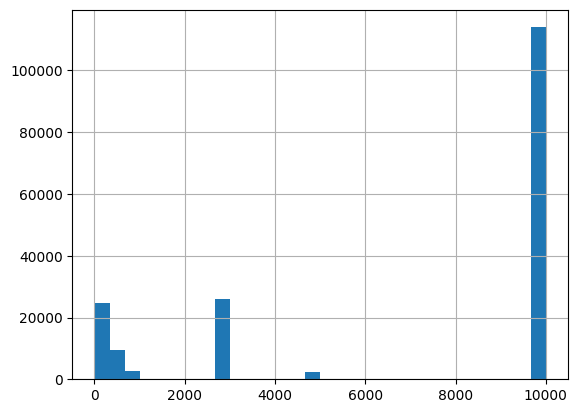

In [4]:
df_physical.tan_beta.hist(bins=30)

<Axes: >

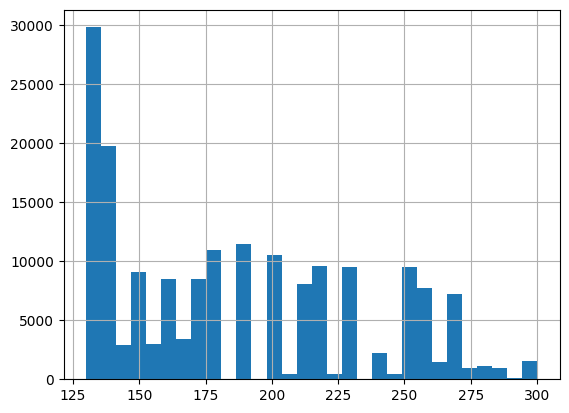

In [5]:
df_physical.m_phi.hist(bins=30)

In [6]:
(df_physical["m_phi"] < 141).sum()

np.int64(49540)

In [7]:
df_physical.columns

Index(['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba',
       'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok',
       'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga',
       'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1',
       'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5', 'm_A',
       'lambda_6', 'lambda_7', 'm12_2', 'w_h2_bb', 'w_h2_tautau', 'w_h2_uu',
       'w_h2_du', 'w_h2_ln', 'w_h2_vv', 'w_h2_gaga', 'w_h2_Zga', 'w_h2_gg',
       'w_h2_hh', 'w_total_h2', 'w_total_top', 'branching_ratio_h2_gaga',
       'lambda1', 'lambda2', 'lambda3', 'lambda4', 'lambda5'],
      dtype='object')

In [8]:
set(df_physical.tan_beta)

{10.0,
 20.0,
 100.0,
 200.0,
 300.0,
 500.0,
 600.0,
 1000.0,
 3000.0,
 5000.0,
 10000.0}

In [9]:
print(df_physical.columns.tolist())

['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba', 'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok', 'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga', 'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1', 'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5', 'm_A', 'lambda_6', 'lambda_7', 'm12_2', 'w_h2_bb', 'w_h2_tautau', 'w_h2_uu', 'w_h2_du', 'w_h2_ln', 'w_h2_vv', 'w_h2_gaga', 'w_h2_Zga', 'w_h2_gg', 'w_h2_hh', 'w_total_h2', 'w_total_top', 'branching_ratio_h2_gaga', 'lambda1', 'lambda2', 'lambda3', 'lambda4', 'lambda5']


In [10]:
# Valores fijos (mismos que en physpoint y simulate_curve)
fixed_mA      = 300.0
fixed_sin_ba  = 0.9990
fixed_lambda6 = 0.1
fixed_lambda7 = 0.0

# Valores de tan_beta a considerar
tan_beta_vals = set(df_physical.tan_beta)


def get_curve(df, fixed_mA, fixed_sin_ba, fixed_lambda6, fixed_lambda7, tan_beta_vals, tol=1e-3):
    # Filtro por parámetros fijos (excepto tan_beta)
    mask_fixed = (
        (df['mA'].sub(fixed_mA).abs() < tol) &
        (df['sin_ba'].sub(fixed_sin_ba).abs() < tol) &
        (df['lambda6'].sub(fixed_lambda6).abs() < tol) &
        (df['lambda7'].sub(fixed_lambda7).abs() < tol) &
        (df['tan_beta'].isin(tan_beta_vals))
    )
    return df.loc[mask_fixed].copy().reset_index(drop=True)

df_physical_curve = get_curve(df_physical, fixed_mA, fixed_sin_ba, fixed_lambda6, fixed_lambda7, tan_beta_vals, tol=1e-3)



In [11]:
# # # ==== extrae un valor de ejemplo =====
# fixed_mphi = 200
# mask_phi = df_physical['m_phi'].sub(fixed_mphi).abs() < 1
# df_curve.loc[mask_phi].iloc[0]

In [12]:
# --- Paso 4: Ordenar por m_phi y extraer mphi / m12_2 ---
df_curve = df_physical_curve.sort_values(by='m_phi').reset_index(drop=True)

# Vector de valores de m_phi (ordenados ascendentemente)
mphi_values = df_curve['m_phi'].to_numpy()

# Vector de valores de m12_2 correspondientes a cada m_phi
m12_values  = df_curve['m12'].to_numpy()


In [13]:
df_curve.columns

Index(['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba',
       'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok',
       'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga',
       'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1',
       'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5', 'm_A',
       'lambda_6', 'lambda_7', 'm12_2', 'w_h2_bb', 'w_h2_tautau', 'w_h2_uu',
       'w_h2_du', 'w_h2_ln', 'w_h2_vv', 'w_h2_gaga', 'w_h2_Zga', 'w_h2_gg',
       'w_h2_hh', 'w_total_h2', 'w_total_top', 'branching_ratio_h2_gaga',
       'lambda1', 'lambda2', 'lambda3', 'lambda4', 'lambda5'],
      dtype='object')

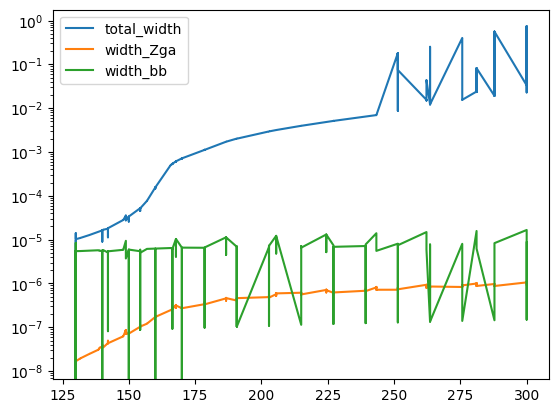

In [14]:
plt.plot(df_curve["m_phi"],df_curve["total_width"], label='total_width')
plt.plot(df_curve["m_phi"],df_curve["width_Zga"], label='width_Zga')
plt.plot(df_curve["m_phi"],df_curve["width_bb"], label='width_bb')
plt.legend()
plt.yscale('log')
plt.show()


In [15]:
set(df_physical.mA)

{nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 300.0,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 n

Resumen cobertura:

-- tanβ=100.0 -- N=982 -- Cobertura(bins>0): 25.6%
   min_phi=130.00, max_phi=300.00
-- tanβ=1000.0 -- N=2736 -- Cobertura(bins>0): 15.4%
   min_phi=130.00, max_phi=170.00
-- tanβ=200.0 -- N=7350 -- Cobertura(bins>0): 38.5%
   min_phi=130.00, max_phi=300.00
-- tanβ=10.0 -- N=3643 -- Cobertura(bins>0): 25.6%
   min_phi=130.00, max_phi=300.00
-- tanβ=5000.0 -- N=2282 -- Cobertura(bins>0): 2.6%
   min_phi=130.00, max_phi=130.00
-- tanβ=300.0 -- N=5346 -- Cobertura(bins>0): 28.2%
   min_phi=130.00, max_phi=251.43
-- tanβ=600.0 -- N=2839 -- Cobertura(bins>0): 15.4%
   min_phi=130.00, max_phi=190.71
-- tanβ=10000.0 -- N=733 -- Cobertura(bins>0): 2.6%
   min_phi=130.00, max_phi=130.00
-- tanβ=20.0 -- N=7407 -- Cobertura(bins>0): 38.5%
   min_phi=130.00, max_phi=300.00
-- tanβ=500.0 -- N=6679 -- Cobertura(bins>0): 17.9%
   min_phi=130.00, max_phi=202.86
-- tanβ=3000.0 -- N=25965 -- Cobertura(bins>0): 7.7%
   min_phi=130.00, max_phi=140.30


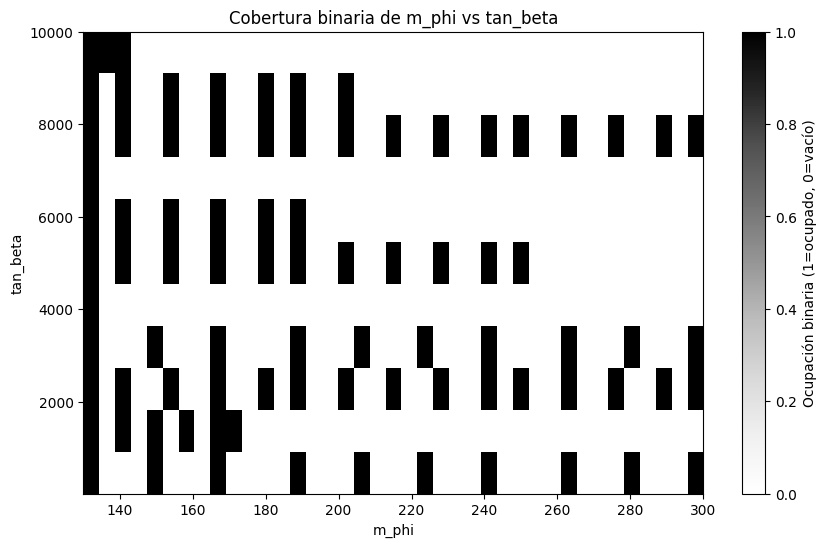

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros fijos (salvo tan_beta) ---
fixed_mA      = 300.0
fixed_sin_ba  = 0.9990
fixed_lambda6 = 0.1
fixed_lambda7 = 0.0
tol = 1e-8

# --- Máscara de selección (excluye tan_beta) ---
mask_fixed = (
    (df_physical['mA'].sub(fixed_mA).abs()       < tol) &
    (df_physical['sin_ba'].sub(fixed_sin_ba).abs() < tol) &
    (df_physical['lambda6'].sub(fixed_lambda6).abs() < tol) &
    (df_physical['lambda7'].sub(fixed_lambda7).abs() < tol)
)

df_curve = df_physical.loc[mask_fixed].copy().reset_index(drop=True)

if df_curve.empty:
    raise RuntimeError("No se encontraron puntos con esos parámetros fijos.")

# --- Valores de tan_beta a estudiar ---
tan_betas = set(df_physical.tan_beta)

# --- Definir bins de m_phi ---
bins = np.linspace(df_curve['m_phi'].min(), df_curve['m_phi'].max(), 40)
heatmap = np.zeros((len(tan_betas), len(bins)-1))

print("Resumen cobertura:\n")
for i, tb in enumerate(tan_betas):
    df_tb = df_curve[df_curve["tan_beta"] == tb]
    counts, _ = np.histogram(df_tb['m_phi'], bins=bins)
    heatmap[i, :] = (counts > 0).astype(int)

    coverage = 100 * (counts > 0).sum() / len(counts)
    if not df_tb.empty:
        print(f"-- tanβ={tb} -- N={len(df_tb)} -- Cobertura(bins>0): {coverage:.1f}%\n"
              f"   min_phi={df_tb['m_phi'].min():.2f}, max_phi={df_tb['m_phi'].max():.2f}")
    else:
        print(f"-- tanβ={tb} -- N=0 -- Cobertura=0%")

# --- Graficar heatmap binario ---
plt.figure(figsize=(10,6))
plt.imshow(heatmap, aspect="auto", cmap="Greys",
           extent=[bins.min(), bins.max(), min(tan_betas), max(tan_betas)],
           origin="lower")
plt.colorbar(label="Ocupación binaria (1=ocupado, 0=vacío)")
plt.xlabel("m_phi")
plt.ylabel("tan_beta")
plt.title("Cobertura binaria de m_phi vs tan_beta")
plt.show()


# Distintos BR
Vamos a observar de los datos extraidos distintos valores de branching ratio

Ploteando para tanβ=10.0, N=3643


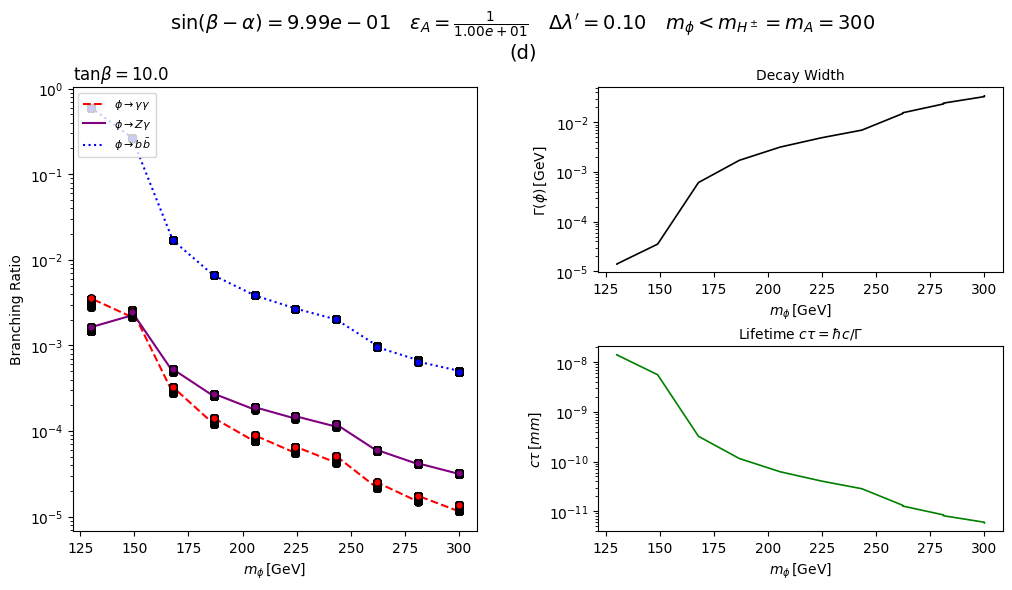

Ploteando para tanβ=20.0, N=7407


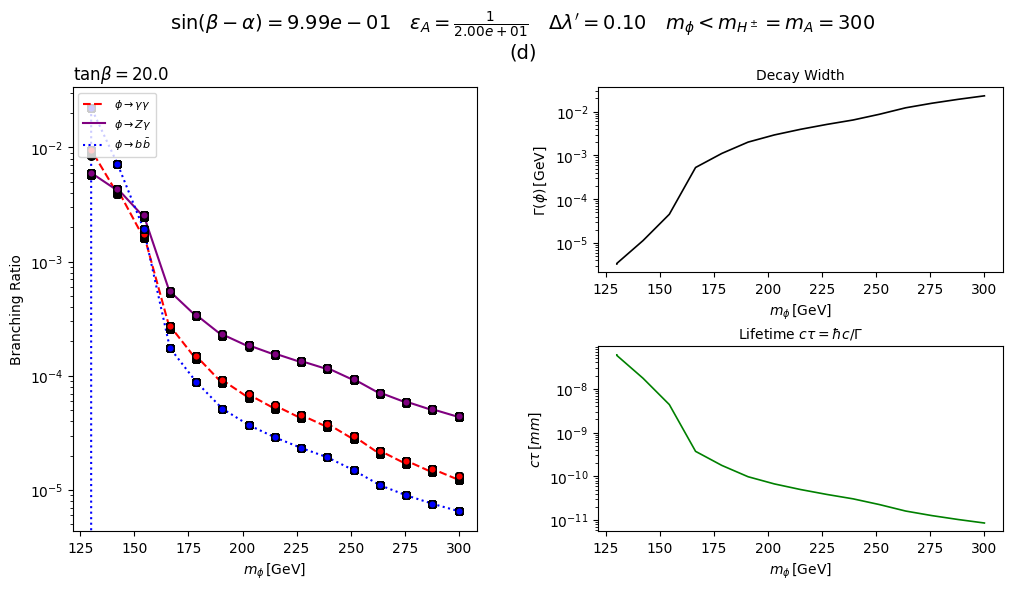

Ploteando para tanβ=100.0, N=982


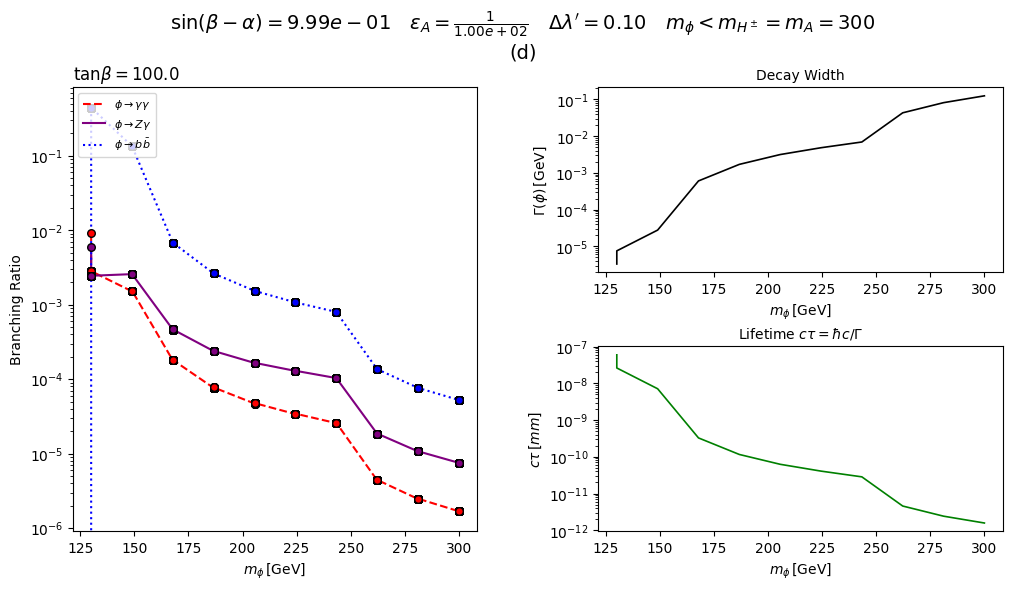

Ploteando para tanβ=200.0, N=7350


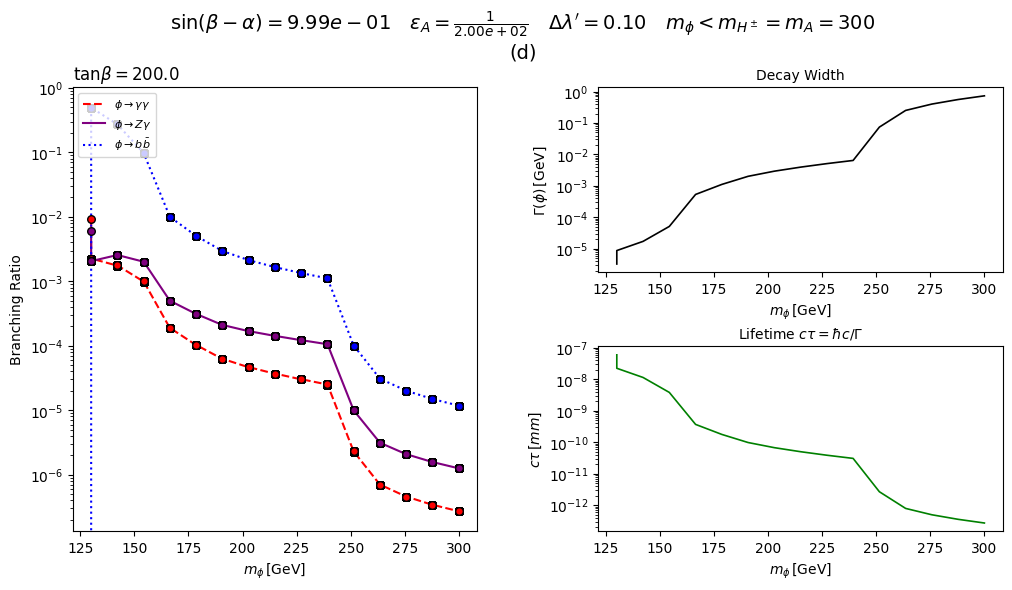

Ploteando para tanβ=300.0, N=5346


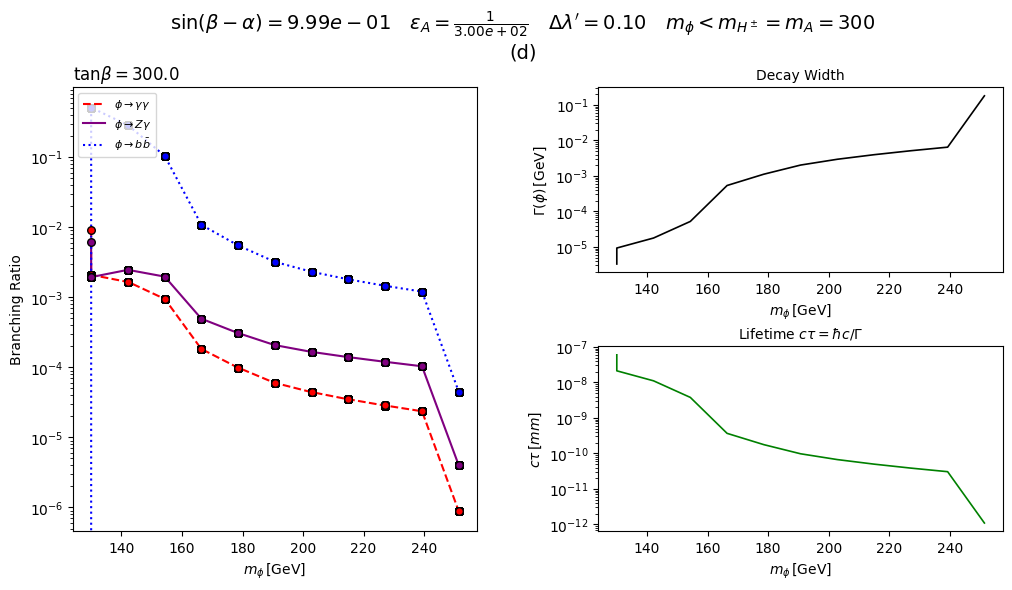

Ploteando para tanβ=500.0, N=6679


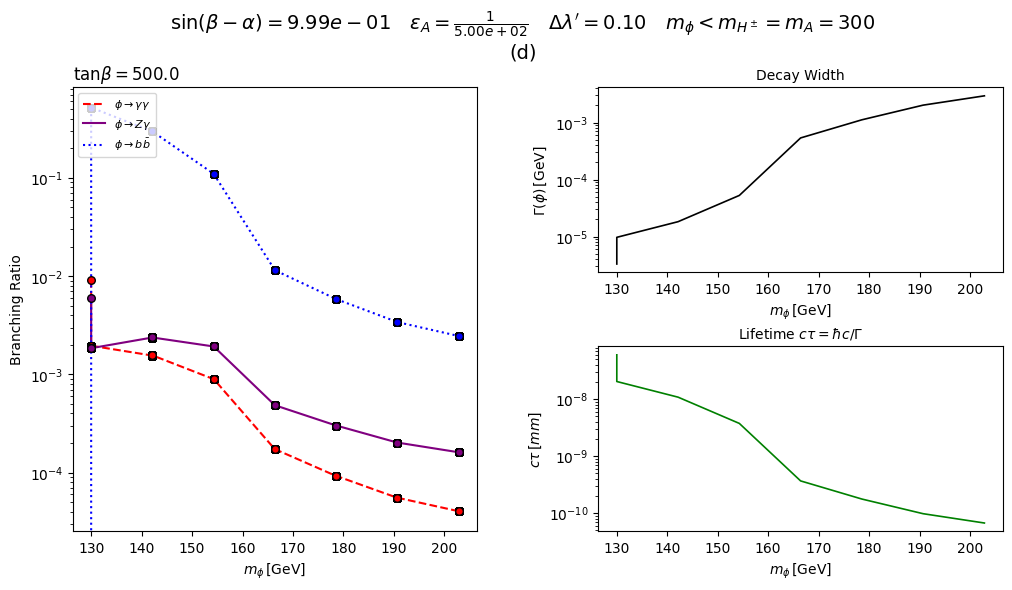

Ploteando para tanβ=600.0, N=2839


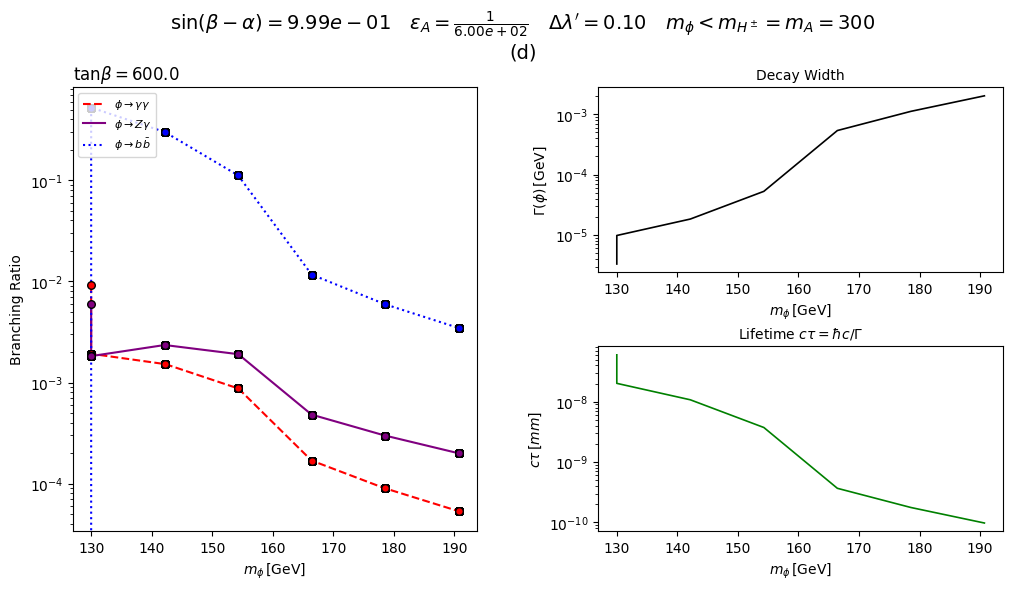

Ploteando para tanβ=1000.0, N=2736


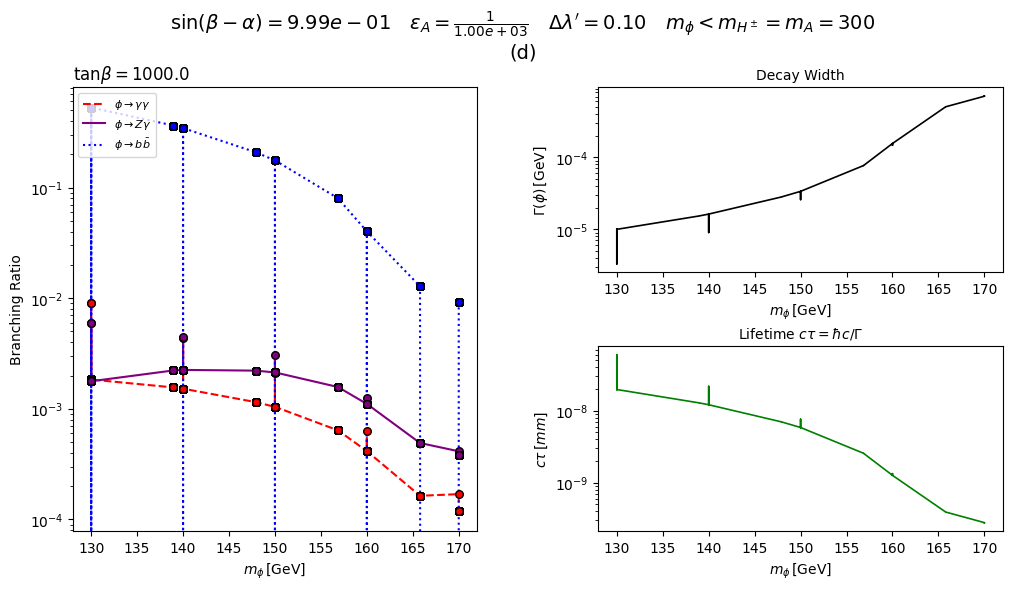

Ploteando para tanβ=3000.0, N=25965


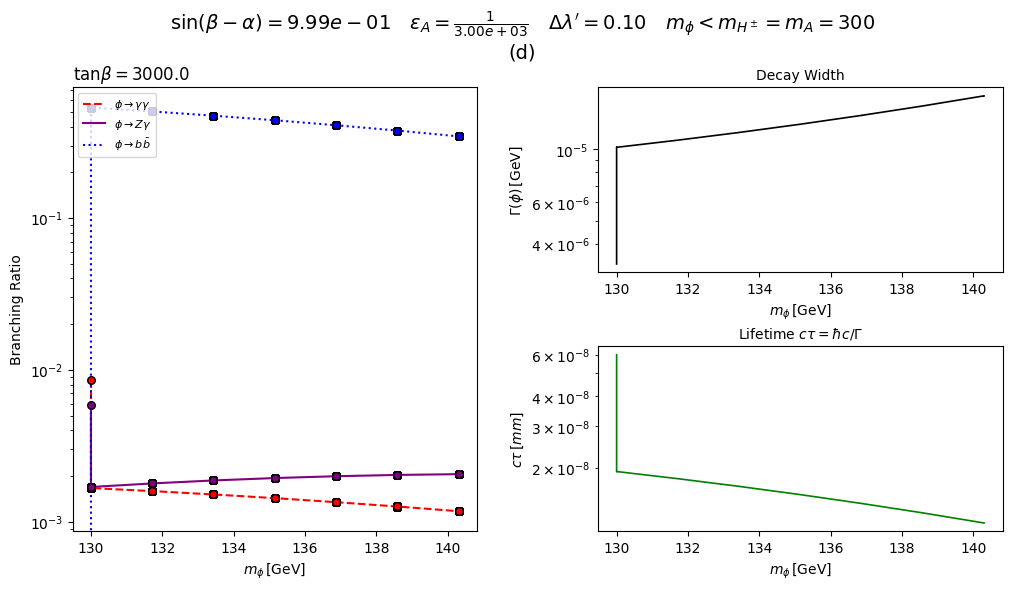

Ploteando para tanβ=5000.0, N=2282


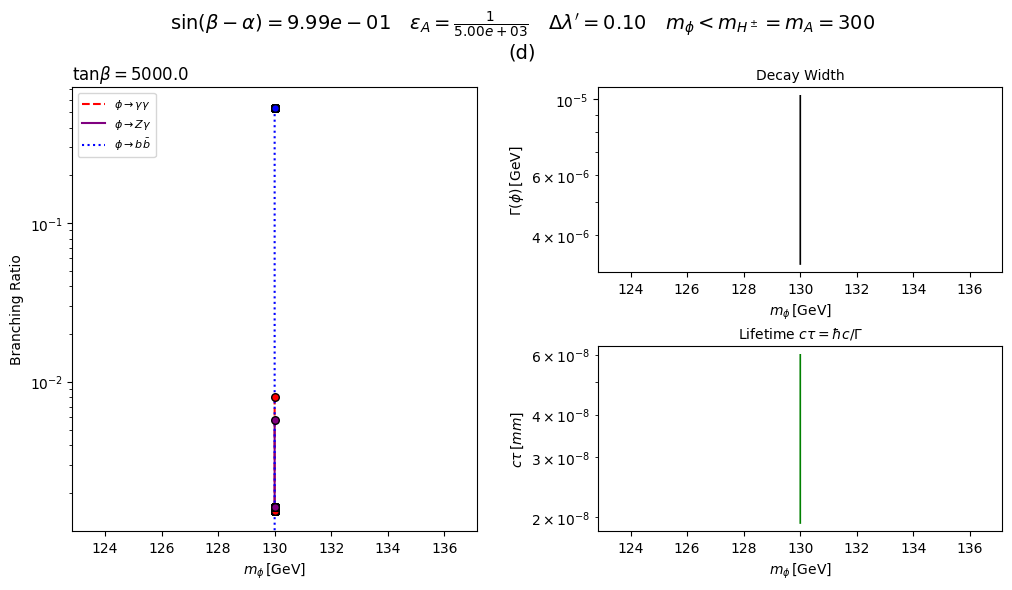

Ploteando para tanβ=10000.0, N=733


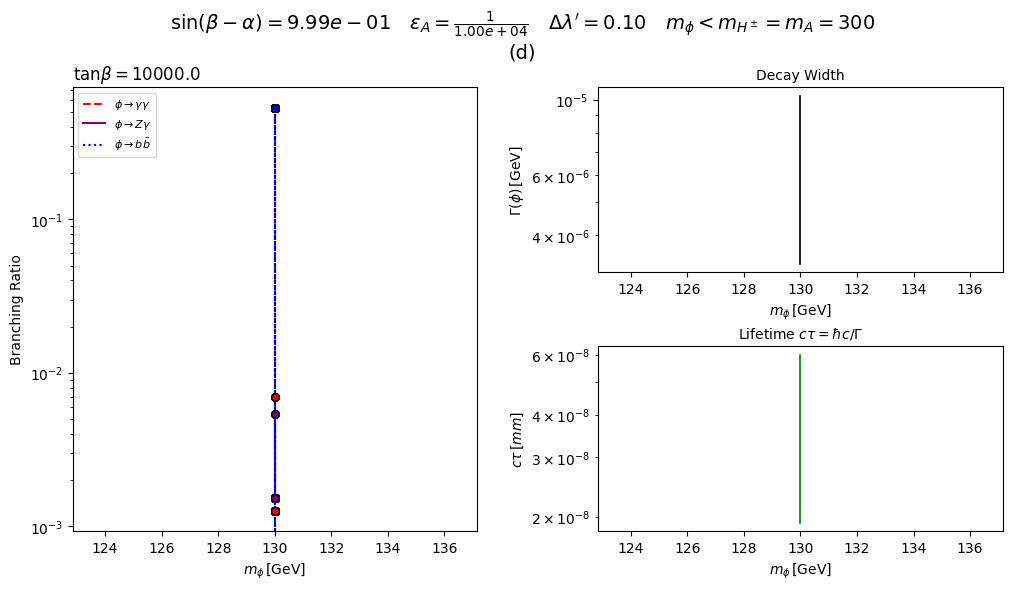

In [17]:
def build_results_for_tb(df_curve, tan_beta_val):
    """Devuelve lista de 'results' filtrados por un tan_beta específico y ordenados por m_phi."""
    
    # --- CAMBIO AQUÍ: Agregamos .sort_values(by='m_phi') ---
    subset = df_curve[np.isclose(df_curve["tan_beta"], tan_beta_val, rtol=1e-5)].sort_values(by='m_phi')
    
    results = []
    for _, row in subset.iterrows():
        total_w = row['total_width']
        
        # Validación de ancho total
        if total_w is None or total_w == 0 or np.isnan(total_w):
            br_Zga = None
            br_bb  = None
        else:
            br_Zga = row['width_Zga'] / total_w
            br_bb  = row['width_bb'] / total_w

        entry = {
            'mphi': float(row['m_phi']),
            'br': {
                'gaga': float(row['br_gaga']),
                'Zga':  float(br_Zga),
                'bb':   float(br_bb)
            },
            'total_width': float(total_w),
            'flags': {
                'positivity':     int(row['positivity_ok']),
                'unitarity':      int(row['unitarity_ok']),
                'perturbativity': int(row['perturbativity_ok'])
            },
            'params': {
                'mA':       fixed_mA,       # Asegúrate que estas variables globales existen
                'm12':      float(row['m12']),
                'lambda6':  fixed_lambda6,  # Asegúrate que estas variables globales existen
                'lambda7':  fixed_lambda7,  # Asegúrate que estas variables globales existen
                'sin_ba':   fixed_sin_ba,   # Asegúrate que estas variables globales existen
                'tan_beta': tan_beta_val
            }
        }
        results.append(entry)
    return results
# --- Paso 6: Generar plots para cada tan_beta ---
tan_betas = sorted(set(df_physical.tan_beta))

for tb in tan_betas:
    results_tb = build_results_for_tb(df_curve, tb)
    if not results_tb:
        print(f"[WARNING] No hay datos para tanβ={tb}")
        continue

    print(f"Ploteando para tanβ={tb}, N={len(results_tb)}")
    plot_branchings_and_lifetime(
        results_tb,
        subplot_tag=fr"tan$\beta={tb}$",
        lifetime_unit="mm",
        lifetime_log=True,
        width_log=True,
        br_log=True
    )



## Exclusivamente ver lifetime

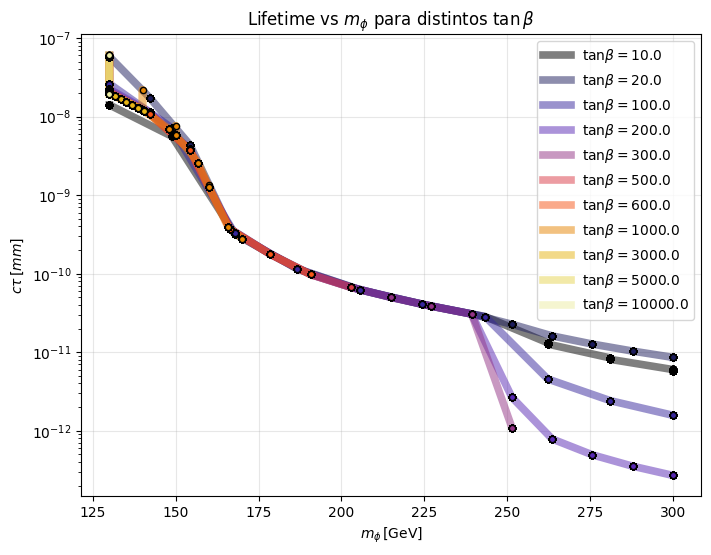

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_lifetime_vs_mphi(
    df_curve,
    tan_betas,
    lifetime_unit: str = "mm",
    lifetime_log: bool = True
):
    """
    Plotea la vida media cτ(m_phi) para distintos slices de tan_beta.

    df_curve: DataFrame filtrado (ya con parámetros fijos excepto tan_beta).
    tan_betas: lista de valores de tan_beta a recorrer.
    lifetime_unit: "mm", "cm" o "m".
    lifetime_log: True → eje y en escala log.
    """
    # Constantes
    hbar = 6.582119569e-25    # GeV·s
    c    = 2.99792458e11      # mm/s
    unit_factors = {"mm": 1.0, "cm": 0.1, "m": 1e-3}
    if lifetime_unit not in unit_factors:
        raise ValueError(f"Unknown lifetime_unit '{lifetime_unit}'")

    plt.figure(figsize=(8,6))
    cmap = plt.cm.CMRmap#plt.cm.viridis
    colors = [cmap(i/len(tan_betas)) for i in range(len(tan_betas))]

    for i, tb in enumerate(tan_betas):
        subset = df_curve[np.isclose(df_curve["tan_beta"], tb, rtol=1e-5)]
        if subset.empty:
            print(f"[WARNING] No hay datos para tanβ={tb}")
            continue

        mphi = subset["m_phi"].values
        total_w = subset["total_width"].values
        c_tau_mm = hbar * c / total_w
        c_tau = c_tau_mm * unit_factors[lifetime_unit]

        # Ordenar por mphi para líneas limpias
        order = np.argsort(mphi)
        mphi, c_tau = mphi[order], c_tau[order]

        plt.plot(mphi, c_tau, label=fr"tan$\beta={tb}$", color=colors[i], lw=5.5, alpha=0.5)
        plt.scatter(mphi, c_tau, color=colors[i], edgecolors="k", s=20, zorder=5)

    plt.xlabel(r"$m_\phi\,[\mathrm{GeV}]$")
    plt.ylabel(rf"$c\tau\,[{lifetime_unit}]$")
    if lifetime_log:
        plt.yscale("log")
    plt.title(r"Lifetime vs $m_\phi$ para distintos $\tan \beta$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

tan_betas = sorted(set(df_physical.tan_beta))
plot_lifetime_vs_mphi(df_curve, tan_betas, lifetime_unit="mm", lifetime_log=True)
